In [1]:
# 1. Clone repository & install ONLY missing helper packages
!git clone https://github.com/ahsan-c0ding/S4-Enhancement-Exploration.git
%cd S4-Enhancement-Exploration
!git checkout python

import os
import sys
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# FIXED: Only install lightweight missing packages (Do NOT reinstall torch/torchvision)
%pip install einops coloredlogs torchinfo --quiet
%pip install git+https://github.com/mwalmsley/galaxy_mnist.git@c1fe9853a00bc34b2ff082585c6bb1654d34d239 --quiet

# Symlink workaround for model_params path resolving
parent_dir = os.path.dirname(current_dir)
_shim_path = os.path.join(parent_dir, "model_params")
_real_path = os.path.join(current_dir, "model_params")
if not os.path.exists(_shim_path) and os.path.exists(_real_path):
    os.symlink(_real_path, _shim_path)

Cloning into 'S4-Enhancement-Exploration'...
remote: Enumerating objects: 1152, done.
remote: Counting objects: 100% (220/220), done.
remote: Compressing objects: 100% (146/146), done.
remote: Total 1152 (delta 88), reused 180 (delta 68), pack-reused 932 (from 2)
Receiving objects: 100% (1152/1152), 94.54 MiB | 35.28 MiB/s, done.
Resolving deltas: 100% (489/489), done.
/kaggle/working/S4-Enhancement-Exploration
Branch 'python' set up to track remote branch 'python' from 'origin'.
Switched to a new branch 'python'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from einops import repeat

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score, roc_auc_score

from model.functions import load_data

warnings.filterwarnings("ignore")
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = [11, 6]

# Reproducibility -- same seed as every other run in this series
RNG_SEED = 30485
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(RNG_SEED)

CLASS_NAMES = ["Smooth Round", "Smooth Cigar", "Edge-on Disk", "Unbarred Spiral"]

# ============================================================================
# PRODUCTION S4D CONFIGURATION (matches the best model -- needed here since
# all three new runs below share everything except one changed variable)
# ============================================================================
COLORED = True
IN_CHANNELS = 3 if COLORED else 1

S4D_STATE = 256
S4D_NUM_LAYERS = 3
S4D_PATCH_SIZE = 4
S4D_POOLING = "last"
S4D_USE_NORM = False
S4D_USE_RESIDUAL = False
S4D_DROPOUT = 0.2
S4D_PATCH_EMBED = "conv"

S4D_BATCH_SIZE = 32
S4D_FINAL_EPOCHS = 630
LEARNING_RATE = 1e-3

# ============================================================================
# RUN 1: POOLING CONFOUND CLOSURE
# ============================================================================
# The earlier "S4D off" ablation necessarily used pooling="mean" (with "last"
# and no S4D, the classifier would only ever see one patch). That means
# "S4D on vs off" also silently changed pooling alongside removing S4D. This
# run isolates that: full production architecture (conv embed, 3 layers,
# d=256), S4D still ON, but pooling switched to "mean" too. If this lands
# near 86.80%, the earlier ~35pp gap really is about S4D, not the pooling
# switch.
POOLING_CONFOUND_D = S4D_STATE              # 256, unchanged
POOLING_CONFOUND_LAYERS = S4D_NUM_LAYERS    # 3, unchanged
POOLING_CONFOUND_POOLING = "mean"           # the only thing that changes
POOLING_CONFOUND_PATCH_EMBED = S4D_PATCH_EMBED  # "conv", unchanged

# ============================================================================
# RUN 2 & 3: ~60-80K PARAMETER BUDGET, CONV VS LINEAR EMBED
# ============================================================================
# Same question as the big-model 2x2 grid, but at a much smaller width: does
# a compact S4D model still get most of its accuracy from S4D rather than the
# conv stem? d_model=d_state=72, 3 layers (only d_model changes from
# production -- same minimal-change methodology as the earlier 64-dim run)
# puts the conv-embed version at ~69.7K params, comfortably in the 60-80K
# target. The linear-embed version at the same width/depth comes in leaner
# still (~35K) since it skips the conv stem's parameters entirely -- if it
# holds up accuracy-wise too, that's an even stronger case against needing
# the conv stem at all.
SMALL_D = 72
SMALL_LAYERS = S4D_NUM_LAYERS     # 3, same depth as production
SMALL_POOLING = S4D_POOLING       # "last", S4D is ON in both small runs

print(f"Device: {DEVICE}")
print(f"Reference S4D Model: {S4D_NUM_LAYERS} layers | d_model={S4D_STATE} | pooling={S4D_POOLING} | embed={S4D_PATCH_EMBED}")
print(f"Run 1 -- Pooling confound: d={POOLING_CONFOUND_D} | layers={POOLING_CONFOUND_LAYERS} | pooling={POOLING_CONFOUND_POOLING} | embed={POOLING_CONFOUND_PATCH_EMBED}")
print(f"Run 2 -- Small conv+S4D:   d={SMALL_D} | layers={SMALL_LAYERS} | pooling={SMALL_POOLING} | embed=conv")
print(f"Run 3 -- Small linear+S4D: d={SMALL_D} | layers={SMALL_LAYERS} | pooling={SMALL_POOLING} | embed=linear")


/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Device: cuda
Reference S4D Model: 3 layers | d_model=256 | pooling=last | embed=conv
Run 1 -- Pooling confound: d=256 | layers=3 | pooling=mean | embed=conv
Run 2 -- Small conv+S4D:   d=72 | layers=3 | pooling=last | embed=conv
Run 3 -- Small linear+S4D: d=72 | layers=3 | pooling=last | embed=linear


In [3]:
class HilbertScan(nn.Module):
    """Reorders patches of a (B, C, H, W) image along a Hilbert curve."""
    def __init__(self, image_size=64, patch_size=1):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size ** 2
        self.register_buffer("indices", self._get_hilbert_indices(self.grid_size))

    @staticmethod
    def _rot(s, x, y, rx, ry):
        if ry == 0:
            if rx == 1:
                x = s - 1 - x
                y = s - 1 - y
            x, y = y, x
        return x, y

    def _d2xy(self, n, d):
        x = y = 0
        t, s = d, 1
        while s < n:
            rx = (t // 2) & 1
            ry = (t ^ rx) & 1
            x, y = self._rot(s, x, y, rx, ry)
            x += s * rx
            y += s * ry
            t //= 4
            s *= 2
        return x, y

    def _get_hilbert_indices(self, grid_size):
        indices = []
        for d in range(grid_size * grid_size):
            x, y = self._d2xy(grid_size, d)
            indices.append(y * grid_size + x)
        return torch.LongTensor(indices)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        patches = x.unfold(2, p, p).unfold(3, p, p)
        patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()
        patches = patches.view(B, self.num_patches, C * p * p)
        return patches[:, self.indices, :]


class TakeLastTimestep(nn.Module):
    def forward(self, x):
        return x[:, -1, :]


class S4DConv(nn.Module):
    """Fast FFT-based parallel convolution S4D layer."""
    def __init__(self, d_model, d_state=64, dt_min=0.001, dt_max=0.1, transposed=True, lr=None):
        super().__init__()
        self.h = d_model
        self.n = d_state
        self.transposed = transposed

        log_dt = torch.rand(self.h) * (math.log(dt_max) - math.log(dt_min)) + math.log(dt_min)
        log_A_real = torch.log(0.5 * torch.ones(self.h, self.n // 2))
        A_imag = math.pi * repeat(torch.arange(self.n // 2), 'n -> h n', h=self.h)
        C_init = torch.randn(self.h, self.n // 2, dtype=torch.cfloat)

        self.register("log_dt", log_dt, lr)
        self.register("log_A_real", log_A_real, lr)
        self.register("A_imag", A_imag, lr)

        self.C = nn.Parameter(torch.view_as_real(C_init))
        self.D = nn.Parameter(torch.randn(self.h))

    def register(self, name, tensor, lr=None):
        if lr == 0.0:
            self.register_buffer(name, tensor)
        else:
            self.register_parameter(name, nn.Parameter(tensor))
            optim = {"weight_decay": 0.0}
            if lr is not None:
                optim["lr"] = lr
            setattr(getattr(self, name), "_optim", optim)

    def forward(self, u):
        if not self.transposed:
            u = u.transpose(-1, -2)
        L = u.size(-1)

        dt = torch.exp(self.log_dt)
        C = torch.view_as_complex(self.C)
        A = -torch.exp(self.log_A_real) + 1j * self.A_imag

        dtA = A * dt.unsqueeze(-1)
        K_exp = torch.exp(dtA.unsqueeze(-1) * torch.arange(L, device=u.device))
        C_tilde = C * (torch.exp(dtA) - 1.) / A
        k = 2 * torch.einsum('hn, hnl -> hl', C_tilde, K_exp).real

        k_f = torch.fft.rfft(k, n=2 * L)
        u_f = torch.fft.rfft(u, n=2 * L)
        y = torch.fft.irfft(u_f * k_f, n=2 * L)[..., :L]
        y = y + u * self.D.unsqueeze(-1)

        if not self.transposed:
            y = y.transpose(-1, -2)
        return y, None


class ConvPatchStem(nn.Module):
    """Convolutional stem for local neighborhood mixing before patch projection."""
    def __init__(self, in_channels, d_model, patch_size):
        super().__init__()
        mid_channels = max(in_channels * 8, 32)
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, stride=1, padding=1),
            nn.GELU(),
            nn.Conv2d(mid_channels, d_model, kernel_size=patch_size, stride=patch_size),
        )

    def forward(self, x):
        return self.net(x)


class GalaxyClassifierS4DFast(nn.Module):
    """Production S4D Classifier."""
    def __init__(self, s4_state=64, d_model=64, num_classes=4, colored=True,
                 num_layers=2, patch_size=1, pooling="last",
                 use_norm=False, use_residual=False, dropout=0.0,
                 patch_embed="linear"):
        super().__init__()
        self.hilbert_channels = 1 if not colored else 3
        self.patch_size = patch_size
        self.pooling = pooling
        self.use_norm = use_norm
        self.use_residual = use_residual
        self.patch_embed = patch_embed

        if patch_embed == "linear":
            self.hilbert_scan = HilbertScan(image_size=64, patch_size=patch_size)
            patch_dim = self.hilbert_channels * patch_size * patch_size
            self.uproject = nn.Linear(patch_dim, d_model)
            self.conv_stem = None
        elif patch_embed == "conv":
            self.conv_stem = ConvPatchStem(self.hilbert_channels, d_model, patch_size)
            self.hilbert_scan = HilbertScan(image_size=64 // patch_size, patch_size=1)
            self.uproject = nn.Identity()

        self.s4_layers = nn.ModuleList([
            S4DConv(d_model=d_model, d_state=s4_state, transposed=False)
            for _ in range(num_layers)
        ])
        self.acts = nn.ModuleList([nn.GELU() for _ in range(num_layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(num_layers)]) if use_norm else None
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        if pooling == "last":
            self.take_last = TakeLastTimestep()
        elif pooling == "mean":
            self.take_last = None
        else:
            raise ValueError(f"Unknown pooling type {pooling}")

        self.fc = nn.Linear(d_model, num_classes)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, return_logits=True):
        if self.patch_embed == "conv":
            feat = self.conv_stem(x)
            x_seq = self.hilbert_scan(feat)
            h = self.uproject(x_seq)
        else:
            x_seq = self.hilbert_scan(x)
            h = self.uproject(x_seq)

        for i, (s4_layer, act) in enumerate(zip(self.s4_layers, self.acts)):
            residual = h
            h_in = self.norms[i](h) if self.use_norm else h
            h_out, _ = s4_layer(h_in)
            h_out = act(h_out)
            h_out = self.drop(h_out)
            h = residual + h_out if self.use_residual else h_out

        pooled = h.mean(dim=1) if self.take_last is None else self.take_last(h)
        logits = self.fc(pooled)

        if return_logits:
            return logits
        return self.softmax(logits)

In [4]:
# Load dataset
X, y_onehot, y = load_data(root="./data", download=True, train=True, colored=COLORED)
X_test, y_test_onehot, y_test = load_data(root="./data", download=True, train=False, colored=COLORED)
NUM_CLASSES = y_onehot.shape[1]

# FIXED: Unpack 4 outputs corresponding to passing X and y
x_train, x_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RNG_SEED, stratify=y
)

# Custom dataset supporting rotation and flip augmentation
class GalaxyDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        lbl = self.labels[idx]
        if self.augment:
            # Random orthogonal rotation
            k = random.randint(0, 3)
            img = torch.rot90(img, k, [1, 2])
            # Random flips
            if random.random() > 0.5:
                img = torch.flip(img, [2])
            if random.random() > 0.5:
                img = torch.flip(img, [1])
        return img, lbl

train_dataset = GalaxyDataset(x_train, y_train, augment=True)
val_dataset = GalaxyDataset(x_val, y_val, augment=False)
test_dataset = GalaxyDataset(X_test, y_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=S4D_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=S4D_BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=S4D_BATCH_SIZE, shuffle=False)

print(f"Data Split -> Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

100%|██████████| 68.7M/68.7M [00:03<00:00, 20.2MB/s]
100%|██████████| 17.3M/17.3M [00:01<00:00, 12.8MB/s]


Original Dataset Size: 8000 samples
Original Dataset Size: 2000 samples
Data Split -> Train: 6400 | Val: 1600 | Test: 2000


In [5]:
def create_s4d_optimizer(model, lr=1e-3, weight_decay=0.01):
    decay_params, no_decay_params, special_params = [], [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if hasattr(param, "_optim"):
            opt_dict = param._optim
            param_lr = opt_dict.get("lr", lr)
            special_params.append({'params': [param], 'lr': param_lr, 'weight_decay': 0.0})
        elif any(k in name for k in ["bias", "norm", "LayerNorm"]):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    groups = [
        {'params': decay_params, 'weight_decay': weight_decay, 'lr': lr},
        {'params': no_decay_params, 'weight_decay': 0.0, 'lr': lr},
    ] + special_params
    return torch.optim.AdamW(groups)


def train_s4d_production(model, train_loader, val_loader, epochs=S4D_FINAL_EPOCHS, lr=LEARNING_RATE, device=DEVICE, ckpt_name="s4d_production_best.pt"):
    model.to(device)
    optimizer = create_s4d_optimizer(model, lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-5
    )
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    os.makedirs("checkpoints", exist_ok=True)
    best_ckpt_path = f"checkpoints/{ckpt_name}"  # parametrized so different runs don't clobber each other's checkpoint

    start_time = time.time()
    print(f"Starting S4D production training for {epochs} epochs...")

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images, return_logits=True)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(-1) == labels).sum().item()
            total += labels.size(0)

        scheduler.step()
        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                logits = model(images, return_logits=True)
                val_correct += (logits.argmax(-1) == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_ckpt_path)

        if (epoch + 1) % 25 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} (Best: {best_val_acc:.4f})")

    elapsed = time.time() - start_time
    print(f"\nTraining completed in {elapsed/60:.2f} mins. Best Validation Accuracy: {best_val_acc*100:.2f}%")
    
    # Load best checkpoint
    model.load_state_dict(torch.load(best_ckpt_path))
    return model, history


def evaluate_on_test(model, test_loader, device=DEVICE):
    """Runs a trained model on the test set and returns every metric we report."""
    model.eval()
    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            probs = model(images, return_logits=False)
            preds = probs.argmax(-1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    all_probs = np.array(all_probs)
    return {
        "accuracy": accuracy_score(all_targets, all_preds),
        "f1": f1_score(all_targets, all_preds, average="macro"),
        "precision": precision_score(all_targets, all_preds, average="macro"),
        "recall": recall_score(all_targets, all_preds, average="macro"),
        "auc": roc_auc_score(all_targets, all_probs, multi_class="ovr", average="macro"),
        "preds": all_preds,
        "targets": all_targets,
    }


In [6]:
# Run 1: pooling confound closure -- full production architecture, S4D on,
# pooling switched from "last" to "mean".
pooling_confound_model = GalaxyClassifierS4DFast(
    s4_state=POOLING_CONFOUND_D,
    d_model=POOLING_CONFOUND_D,
    num_classes=NUM_CLASSES,
    colored=COLORED,
    num_layers=POOLING_CONFOUND_LAYERS,
    patch_size=S4D_PATCH_SIZE,
    pooling=POOLING_CONFOUND_POOLING,
    use_norm=S4D_USE_NORM,
    use_residual=S4D_USE_RESIDUAL,
    dropout=S4D_DROPOUT,
    patch_embed=POOLING_CONFOUND_PATCH_EMBED
)

best_pooling_confound_model, pooling_confound_history = train_s4d_production(
    pooling_confound_model, train_loader, val_loader,
    epochs=S4D_FINAL_EPOCHS, ckpt_name="pooling_confound_best.pt"
)


Starting S4D production training for 630 epochs...
Epoch 025/630 | Train Loss: 0.6027 | Train Acc: 0.7473 | Val Acc: 0.7506 (Best: 0.7506)
Epoch 050/630 | Train Loss: 0.5249 | Train Acc: 0.7822 | Val Acc: 0.7775 (Best: 0.7881)
Epoch 075/630 | Train Loss: 0.5237 | Train Acc: 0.7766 | Val Acc: 0.7581 (Best: 0.7950)
Epoch 100/630 | Train Loss: 0.4650 | Train Acc: 0.8081 | Val Acc: 0.7894 (Best: 0.8131)
Epoch 125/630 | Train Loss: 0.4161 | Train Acc: 0.8217 | Val Acc: 0.8200 (Best: 0.8250)
Epoch 150/630 | Train Loss: 0.3933 | Train Acc: 0.8342 | Val Acc: 0.8244 (Best: 0.8263)
Epoch 175/630 | Train Loss: 0.4197 | Train Acc: 0.8225 | Val Acc: 0.8100 (Best: 0.8263)
Epoch 200/630 | Train Loss: 0.3904 | Train Acc: 0.8325 | Val Acc: 0.8219 (Best: 0.8263)
Epoch 225/630 | Train Loss: 0.3621 | Train Acc: 0.8416 | Val Acc: 0.8294 (Best: 0.8313)
Epoch 250/630 | Train Loss: 0.3386 | Train Acc: 0.8562 | Val Acc: 0.8300 (Best: 0.8356)
Epoch 275/630 | Train Loss: 0.3141 | Train Acc: 0.8669 | Val Acc: 0.8

In [7]:
# Run 2: ~60-80K parameter budget, conv embed, S4D on.
small_conv_model = GalaxyClassifierS4DFast(
    s4_state=SMALL_D,
    d_model=SMALL_D,
    num_classes=NUM_CLASSES,
    colored=COLORED,
    num_layers=SMALL_LAYERS,
    patch_size=S4D_PATCH_SIZE,
    pooling=SMALL_POOLING,
    use_norm=S4D_USE_NORM,
    use_residual=S4D_USE_RESIDUAL,
    dropout=S4D_DROPOUT,
    patch_embed="conv"
)

best_small_conv_model, small_conv_history = train_s4d_production(
    small_conv_model, train_loader, val_loader,
    epochs=S4D_FINAL_EPOCHS, ckpt_name="small_conv_s4d_best.pt"
)


Starting S4D production training for 630 epochs...
Epoch 025/630 | Train Loss: 0.6597 | Train Acc: 0.7197 | Val Acc: 0.7525 (Best: 0.7594)
Epoch 050/630 | Train Loss: 0.5844 | Train Acc: 0.7533 | Val Acc: 0.7656 (Best: 0.7669)
Epoch 075/630 | Train Loss: 0.5618 | Train Acc: 0.7630 | Val Acc: 0.7731 (Best: 0.7775)
Epoch 100/630 | Train Loss: 0.4922 | Train Acc: 0.7870 | Val Acc: 0.7881 (Best: 0.7981)
Epoch 125/630 | Train Loss: 0.4614 | Train Acc: 0.8033 | Val Acc: 0.8069 (Best: 0.8094)
Epoch 150/630 | Train Loss: 0.4466 | Train Acc: 0.8119 | Val Acc: 0.8075 (Best: 0.8100)
Epoch 175/630 | Train Loss: 0.4473 | Train Acc: 0.8055 | Val Acc: 0.7994 (Best: 0.8187)
Epoch 200/630 | Train Loss: 0.4281 | Train Acc: 0.8194 | Val Acc: 0.8225 (Best: 0.8225)
Epoch 225/630 | Train Loss: 0.4025 | Train Acc: 0.8283 | Val Acc: 0.8275 (Best: 0.8387)
Epoch 250/630 | Train Loss: 0.3790 | Train Acc: 0.8394 | Val Acc: 0.8263 (Best: 0.8387)
Epoch 275/630 | Train Loss: 0.3641 | Train Acc: 0.8453 | Val Acc: 0.8

In [8]:
# Run 3: same width/depth as Run 2, but linear patch embed instead of conv --
# tests whether the conv stem is pulling its weight at this smaller budget too.
small_linear_model = GalaxyClassifierS4DFast(
    s4_state=SMALL_D,
    d_model=SMALL_D,
    num_classes=NUM_CLASSES,
    colored=COLORED,
    num_layers=SMALL_LAYERS,
    patch_size=S4D_PATCH_SIZE,
    pooling=SMALL_POOLING,
    use_norm=S4D_USE_NORM,
    use_residual=S4D_USE_RESIDUAL,
    dropout=S4D_DROPOUT,
    patch_embed="linear"
)

best_small_linear_model, small_linear_history = train_s4d_production(
    small_linear_model, train_loader, val_loader,
    epochs=S4D_FINAL_EPOCHS, ckpt_name="small_linear_s4d_best.pt"
)


Starting S4D production training for 630 epochs...
Epoch 025/630 | Train Loss: 0.7532 | Train Acc: 0.6736 | Val Acc: 0.7163 (Best: 0.7169)
Epoch 050/630 | Train Loss: 0.6690 | Train Acc: 0.7170 | Val Acc: 0.7500 (Best: 0.7500)
Epoch 075/630 | Train Loss: 0.6569 | Train Acc: 0.7211 | Val Acc: 0.7488 (Best: 0.7519)
Epoch 100/630 | Train Loss: 0.6107 | Train Acc: 0.7362 | Val Acc: 0.7631 (Best: 0.7631)
Epoch 125/630 | Train Loss: 0.5695 | Train Acc: 0.7575 | Val Acc: 0.7719 (Best: 0.7719)
Epoch 150/630 | Train Loss: 0.5595 | Train Acc: 0.7589 | Val Acc: 0.7625 (Best: 0.7719)
Epoch 175/630 | Train Loss: 0.5728 | Train Acc: 0.7580 | Val Acc: 0.7712 (Best: 0.7731)
Epoch 200/630 | Train Loss: 0.5600 | Train Acc: 0.7625 | Val Acc: 0.7662 (Best: 0.7806)
Epoch 225/630 | Train Loss: 0.5395 | Train Acc: 0.7692 | Val Acc: 0.7837 (Best: 0.7856)
Epoch 250/630 | Train Loss: 0.5195 | Train Acc: 0.7755 | Val Acc: 0.7850 (Best: 0.7856)
Epoch 275/630 | Train Loss: 0.5069 | Train Acc: 0.7837 | Val Acc: 0.7

Pooling Confound (conv+S4D, mean pool) -- Test Set Results
Accuracy:        85.45%
Macro-F1:        0.8544
Macro-Precision: 0.8560
Macro-Recall:    0.8546
Macro-AUC (OVR): 0.9716

Small Conv+S4D (~70K) -- Test Set Results
Accuracy:        85.15%
Macro-F1:        0.8522
Macro-Precision: 0.8528
Macro-Recall:    0.8520
Macro-AUC (OVR): 0.9727

Small Linear+S4D (~35K) -- Test Set Results
Accuracy:        80.20%
Macro-F1:        0.8028
Macro-Precision: 0.8043
Macro-Recall:    0.8033
Macro-AUC (OVR): 0.9562



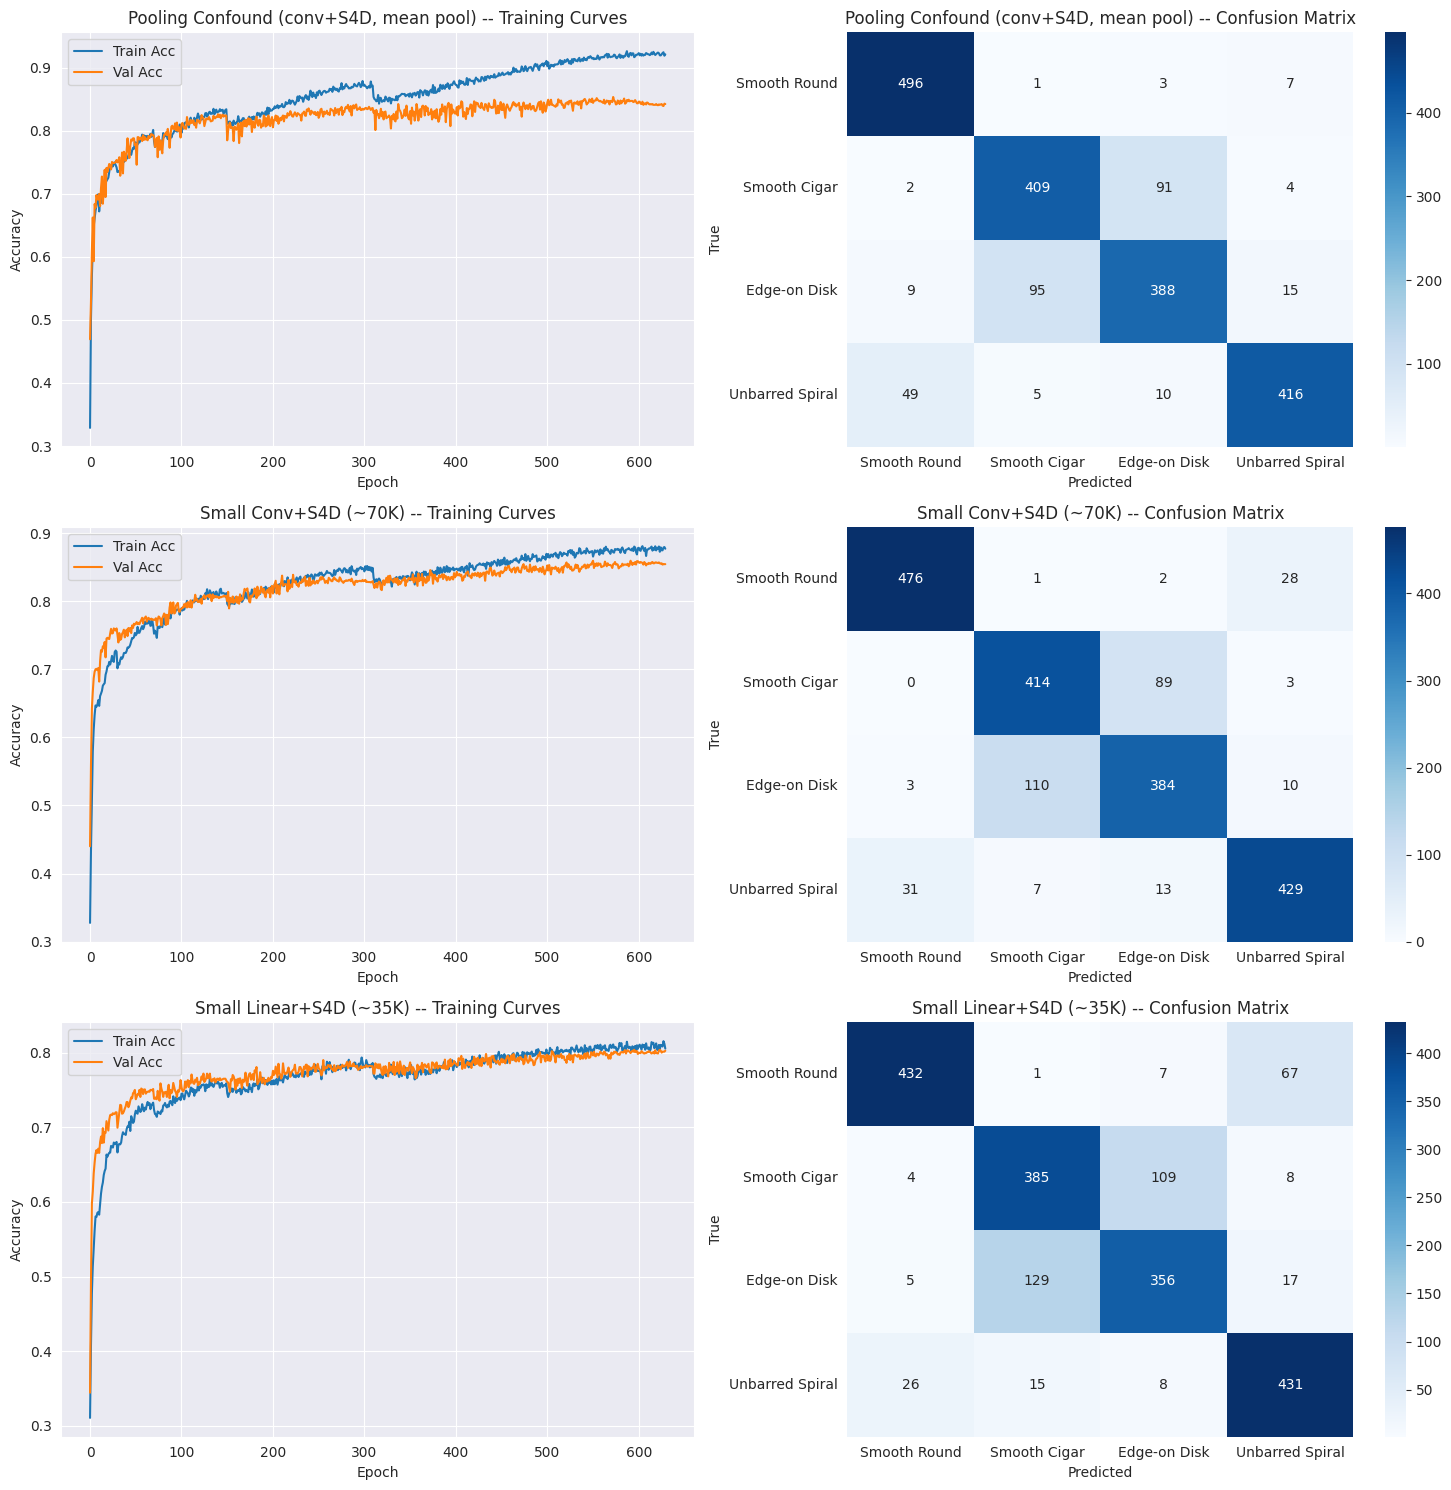

In [9]:
runs = [
    ("Pooling Confound (conv+S4D, mean pool)", best_pooling_confound_model, pooling_confound_history),
    ("Small Conv+S4D (~70K)", best_small_conv_model, small_conv_history),
    ("Small Linear+S4D (~35K)", best_small_linear_model, small_linear_history),
]

results = {}
for name, model, history in runs:
    res = evaluate_on_test(model, test_loader)
    results[name] = res
    print("=" * 50)
    print(f"{name} -- Test Set Results")
    print("=" * 50)
    print(f"Accuracy:        {res['accuracy'] * 100:.2f}%")
    print(f"Macro-F1:        {res['f1']:.4f}")
    print(f"Macro-Precision: {res['precision']:.4f}")
    print(f"Macro-Recall:    {res['recall']:.4f}")
    print(f"Macro-AUC (OVR): {res['auc']:.4f}")
    print("=" * 50)
    print()

# Training curves + confusion matrices, all three runs stacked
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

for i, (name, model, history) in enumerate(runs):
    axes[i, 0].plot(history["train_acc"], label="Train Acc")
    axes[i, 0].plot(history["val_acc"], label="Val Acc")
    axes[i, 0].set_title(f"{name} -- Training Curves")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 0].set_ylabel("Accuracy")
    axes[i, 0].legend()

    res = results[name]
    cm = confusion_matrix(res["targets"], res["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[i, 1])
    axes[i, 1].set_title(f"{name} -- Confusion Matrix")
    axes[i, 1].set_xlabel("Predicted")
    axes[i, 1].set_ylabel("True")

plt.tight_layout()
plt.show()


In [10]:
from torchinfo import summary

def count_params(model):
    return sum(p.numel() for p in model.parameters())

# Everything trained in earlier notebooks -- copied verbatim from their
# verified torchinfo output. Only the three new models below get freshly counted.
param_counts = {
    "Best S4D (3L, d=256)": 528_004,
    "2-Layer S4D (d=256)": 396_420,
    "64x64-dim S4D (3L)": 58_948,
    "Conv Embed + No S4D": 133_252,
    "Linear Embed + S4D": 408_324,
    "Linear Embed + No S4D": 13_572,
    "Pooling Confound (conv+S4D, mean pool)": count_params(best_pooling_confound_model),
    "Small Conv+S4D (~70K)": count_params(best_small_conv_model),
    "Small Linear+S4D (~35K)": count_params(best_small_linear_model),
}

for name, n in param_counts.items():
    print(f"{name:42s} {n:>10,} params")

print("\nFull layer-by-layer breakdown -- Small Conv+S4D:")
summary(best_small_conv_model, input_size=(S4D_BATCH_SIZE, IN_CHANNELS, 64, 64))

print("\nFull layer-by-layer breakdown -- Small Linear+S4D:")
summary(best_small_linear_model, input_size=(S4D_BATCH_SIZE, IN_CHANNELS, 64, 64))


Best S4D (3L, d=256)                          528,004 params
2-Layer S4D (d=256)                           396,420 params
64x64-dim S4D (3L)                             58,948 params
Conv Embed + No S4D                           133,252 params
Linear Embed + S4D                            408,324 params
Linear Embed + No S4D                          13,572 params
Pooling Confound (conv+S4D, mean pool)        528,004 params
Small Conv+S4D (~70K)                          69,660 params
Small Linear+S4D (~35K)                        35,356 params

Full layer-by-layer breakdown -- Small Conv+S4D:

Full layer-by-layer breakdown -- Small Linear+S4D:


Layer (type:depth-idx)                   Output Shape              Param #
GalaxyClassifierS4DFast                  [32, 4]                   --
├─HilbertScan: 1-1                       [32, 256, 48]             --
├─Linear: 1-2                            [32, 256, 72]             3,528
├─ModuleList: 1-9                        --                        (recursive)
│    └─S4DConv: 2-1                      [32, 256, 72]             10,512
├─ModuleList: 1-10                       --                        --
│    └─GELU: 2-2                         [32, 256, 72]             --
├─Dropout: 1-5                           [32, 256, 72]             --
├─ModuleList: 1-9                        --                        (recursive)
│    └─S4DConv: 2-3                      [32, 256, 72]             10,512
├─ModuleList: 1-10                       --                        --
│    └─GELU: 2-4                         [32, 256, 72]             --
├─Dropout: 1-8                           [32, 256, 72]  

In [11]:
import shutil
from IPython.display import FileLink, display

ckpt_names = ["pooling_confound_best.pt", "small_conv_s4d_best.pt", "small_linear_s4d_best.pt"]

for ckpt_name in ckpt_names:
    source_path = f"checkpoints/{ckpt_name}"
    destination_path = f"/kaggle/working/{ckpt_name}"
    if os.path.exists(source_path):
        shutil.copy(source_path, destination_path)
        print(f"✅ {ckpt_name} moved to the root output folder!")
    else:
        print(f"❌ Could not find {ckpt_name} -- did training complete?")

print("\nClick the links below to download your weights:")
os.chdir('/kaggle/working')
for ckpt_name in ckpt_names:
    if os.path.exists(ckpt_name):
        display(FileLink(ckpt_name))
os.chdir('/kaggle/working/S4-Enhancement-Exploration')


✅ pooling_confound_best.pt moved to the root output folder!
✅ small_conv_s4d_best.pt moved to the root output folder!
✅ small_linear_s4d_best.pt moved to the root output folder!

Click the links below to download your weights:


/kaggle/working/pooling_confound_best.pt

/kaggle/working/small_conv_s4d_best.pt

/kaggle/working/small_linear_s4d_best.pt

In [12]:
# ============================================================================
# SUMMARY -- full series, plus the two new questions this notebook answers
# ============================================================================
pooling_confound_res = results["Pooling Confound (conv+S4D, mean pool)"]
small_conv_res = results["Small Conv+S4D (~70K)"]
small_linear_res = results["Small Linear+S4D (~35K)"]

summary_rows = [
    {"Model": "Best S4D (3L, d=256) [conv+S4D, last-pool]", "Test/Val": "Test",
     "Accuracy": 0.8680, "Macro-F1": 0.8688, "Macro-Precision": None, "Macro-Recall": None, "Macro-AUC": None,
     "Params": param_counts["Best S4D (3L, d=256)"]},
    {"Model": "2-Layer S4D (d=256)", "Test/Val": "Test",
     "Accuracy": 0.8640, "Macro-F1": 0.8647, "Macro-Precision": None, "Macro-Recall": None, "Macro-AUC": None,
     "Params": param_counts["2-Layer S4D (d=256)"]},
    {"Model": "64x64-dim S4D (3L)", "Test/Val": "Val",
     "Accuracy": 0.8500, "Macro-F1": None, "Macro-Precision": None, "Macro-Recall": None, "Macro-AUC": None,
     "Params": param_counts["64x64-dim S4D (3L)"]},
    {"Model": "Conv Embed + No S4D [conv+meanpool]", "Test/Val": "Test",
     "Accuracy": 0.5150, "Macro-F1": 0.5156, "Macro-Precision": 0.5205, "Macro-Recall": 0.5169, "Macro-AUC": 0.7730,
     "Params": param_counts["Conv Embed + No S4D"]},
    {"Model": "Linear Embed + S4D", "Test/Val": "Test",
     "Accuracy": 0.8285, "Macro-F1": 0.8290, "Macro-Precision": 0.8299, "Macro-Recall": 0.8294, "Macro-AUC": 0.9621,
     "Params": param_counts["Linear Embed + S4D"]},
    {"Model": "Linear Embed + No S4D", "Test/Val": "Test",
     "Accuracy": 0.3585, "Macro-F1": 0.3528, "Macro-Precision": 0.3613, "Macro-Recall": 0.3604, "Macro-AUC": 0.6195,
     "Params": param_counts["Linear Embed + No S4D"]},
    {"Model": "Pooling Confound (conv+S4D, mean-pool)", "Test/Val": "Test",
     "Accuracy": pooling_confound_res["accuracy"], "Macro-F1": pooling_confound_res["f1"],
     "Macro-Precision": pooling_confound_res["precision"], "Macro-Recall": pooling_confound_res["recall"],
     "Macro-AUC": pooling_confound_res["auc"], "Params": param_counts["Pooling Confound (conv+S4D, mean pool)"]},
    {"Model": "Small Conv+S4D (d=72, 3L, ~70K)", "Test/Val": "Test",
     "Accuracy": small_conv_res["accuracy"], "Macro-F1": small_conv_res["f1"],
     "Macro-Precision": small_conv_res["precision"], "Macro-Recall": small_conv_res["recall"],
     "Macro-AUC": small_conv_res["auc"], "Params": param_counts["Small Conv+S4D (~70K)"]},
    {"Model": "Small Linear+S4D (d=72, 3L, ~35K)", "Test/Val": "Test",
     "Accuracy": small_linear_res["accuracy"], "Macro-F1": small_linear_res["f1"],
     "Macro-Precision": small_linear_res["precision"], "Macro-Recall": small_linear_res["recall"],
     "Macro-AUC": small_linear_res["auc"], "Params": param_counts["Small Linear+S4D (~35K)"]},
]

summary_df = pd.DataFrame(summary_rows).set_index("Model")
summary_df["Accuracy"] = summary_df["Accuracy"].map(lambda x: f"{x*100:.2f}%" if pd.notnull(x) else "N/A")
for col in ["Macro-F1", "Macro-Precision", "Macro-Recall", "Macro-AUC"]:
    summary_df[col] = summary_df[col].map(lambda x: f"{x:.4f}" if pd.notnull(x) else "N/A")
summary_df["Params"] = summary_df["Params"].map(lambda x: f"{x:,}")

print(summary_df.to_string())

# ----------------------------------------------------------------------------
# Question 1: was the earlier "S4D off" gap really about S4D, or partly pooling?
# ----------------------------------------------------------------------------
conv_s4d_last_acc = 0.8680
pooling_confound_acc = pooling_confound_res["accuracy"]

print("\n" + "=" * 60)
print("POOLING CONFOUND CHECK")
print("=" * 60)
print(f"Conv+S4D, last-pool (production):  {conv_s4d_last_acc*100:.2f}%")
print(f"Conv+S4D, mean-pool (this run):    {pooling_confound_acc*100:.2f}%")
print(f"Difference:                        {(conv_s4d_last_acc - pooling_confound_acc)*100:+.2f} pp")
print("Small difference -> pooling choice barely matters when S4D is present,")
print("so the earlier ~35pp 'S4D off' gap is attributable to S4D, not pooling.")
print("Large difference -> pooling strategy was doing more than assumed, and")
print("part of the earlier gap should be credited to the pooling switch too.")

# ----------------------------------------------------------------------------
# Question 2: does a ~60-80K model still get its accuracy from S4D, not conv?
# ----------------------------------------------------------------------------
small_conv_acc = small_conv_res["accuracy"]
small_linear_acc = small_linear_res["accuracy"]
linear_s4d_acc_full = 0.8285

print("\n" + "=" * 60)
print("SMALL-SCALE (~60-80K) CHECK")
print("=" * 60)
print(f"Small Conv+S4D   ({param_counts['Small Conv+S4D (~70K)']:,} params):   {small_conv_acc*100:.2f}%")
print(f"Small Linear+S4D ({param_counts['Small Linear+S4D (~35K)']:,} params): {small_linear_acc*100:.2f}%")
print(f"Conv stem's contribution at this scale: {(small_conv_acc - small_linear_acc)*100:+.2f} pp")
print(f"(at full scale, d=256, it was +3.95 pp)")

print(f"\nSmall Conv+S4D retains {small_conv_acc/conv_s4d_last_acc*100:.1f}% of the full model's accuracy")
print(f"using {param_counts['Small Conv+S4D (~70K)']/param_counts['Best S4D (3L, d=256)']*100:.1f}% of its parameters.")
print(f"Small Linear+S4D retains {small_linear_acc/conv_s4d_last_acc*100:.1f}% of the full model's accuracy")
print(f"using {param_counts['Small Linear+S4D (~35K)']/param_counts['Best S4D (3L, d=256)']*100:.1f}% of its parameters.")


                                           Test/Val Accuracy Macro-F1 Macro-Precision Macro-Recall Macro-AUC   Params
Model                                                                                                                
Best S4D (3L, d=256) [conv+S4D, last-pool]     Test   86.80%   0.8688             N/A          N/A       N/A  528,004
2-Layer S4D (d=256)                            Test   86.40%   0.8647             N/A          N/A       N/A  396,420
64x64-dim S4D (3L)                              Val   85.00%      N/A             N/A          N/A       N/A   58,948
Conv Embed + No S4D [conv+meanpool]            Test   51.50%   0.5156          0.5205       0.5169    0.7730  133,252
Linear Embed + S4D                             Test   82.85%   0.8290          0.8299       0.8294    0.9621  408,324
Linear Embed + No S4D                          Test   35.85%   0.3528          0.3613       0.3604    0.6195   13,572
Pooling Confound (conv+S4D, mean-pool)         Test   85